# Prompt U-Net Version 301 Training

# Changes over v300

## 1. Architecture (`prompt_unet_301.py`)

- **No SE (Squeeze-and-Excitation) channel attention**

## Setup

In [1]:
import os
import sys
import gc
import math as _m
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import mlflow
import tensorflow as tf

tf.keras.mixed_precision.set_global_policy("mixed_float16")

import logging
tf.get_logger().setLevel(logging.ERROR)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

print(f"TF  : {tf.__version__}")
print(f"GPUs: {tf.config.list_physical_devices('GPU')}")

2026-04-17 08:31:51.337937: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-17 08:31:51.358785: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776407511.381283     129 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776407511.388034     129 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776407511.407274     129 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

TF  : 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Allow importing from project root
notebook_dir = Path().resolve()
project_root  = notebook_dir.parent
sys.path.insert(0, str(project_root))

from data.DataLoader_npz import DataLoader_npz
from data.DataGenerator  import DataGenerator

from utils.augmentations  import PromptUNetAugmenter
from utils.metrics        import dice_score_tf
from utils.visualization  import plot_result

from prompt_unet_301 import PromptUNet

## Data Loading

In [3]:
dataset_paths = [
    "data/train_data/nako_combined.npz",
    "data/train_data/total_seg_combined.npz",
    "data/train_data/msd_combined.npz",
]

dataloader    = DataLoader_npz(dataset_paths, val_size=0.01)
datagenerator = DataGenerator(dataloader)

print(f"Image size: {datagenerator.height} x {datagenerator.width}")


Loading NPZ dataset(s)…
Loaded 61 PIDs from /home/dpxuser/prompt-unet/data/train_data/nako_combined.npz
Loaded 45 PIDs from /home/dpxuser/prompt-unet/data/train_data/total_seg_combined.npz
Loaded 40 PIDs from /home/dpxuser/prompt-unet/data/train_data/msd_combined.npz

Final dataset size: 146 patients.

Image size: 128 x 128


## Hyperparameters

In [4]:
version           = "p_unet_301"

epochs            = 4000
batch_size        = 128
dp_training       = 3500
dp_testing        = 1000

offset            = 12
max_number_labels = 4

new_ds       = 50    # refresh training data every N epochs  (was 75 in v292)
new_val_loop = 300   # run validation every N epochs

# LR schedule phases
warmup_epochs = 50
flat_epochs   = 1500

## Model & Optimizer

Custom `WarmupFlatCosineDecay` schedule:
- Phase 1 (50 ep): linear warmup 1e-6 → 1e-3  
- Phase 2 (1500 ep): flat plateau at 1e-3  
- Phase 3 (2450 ep): cosine decay 1e-3 → 1e-5

In [5]:
class WarmupFlatCosineDecay(tf.keras.optimizers.schedules.LearningRateSchedule):
    """
    Three-phase LR schedule:
      1. Linear warmup  : initial_lr → peak_lr over warmup_steps gradient steps.
      2. Flat plateau   : stays at peak_lr for flat_steps gradient steps.
      3. Cosine decay   : peak_lr → min_lr over decay_steps gradient steps.
    """

    def __init__(self, warmup_steps, flat_steps, decay_steps,
                 initial_lr=1e-6, peak_lr=1e-3, alpha=0.01):
        super().__init__()
        self.warmup_steps = float(warmup_steps)
        self.flat_steps   = float(flat_steps)
        self.decay_steps  = float(decay_steps)
        self.initial_lr   = initial_lr
        self.peak_lr      = peak_lr
        self.min_lr       = alpha * peak_lr

    def __call__(self, step):
        step     = tf.cast(step, tf.float32)
        flat_end = self.warmup_steps + self.flat_steps

        # Phase 1: linear warmup
        warmup_frac = tf.minimum(step / self.warmup_steps, 1.0)
        warmup_lr   = self.initial_lr + (self.peak_lr - self.initial_lr) * warmup_frac

        # Phase 3: cosine decay
        decay_step = step - flat_end
        decay_frac = tf.minimum(tf.maximum(decay_step / self.decay_steps, 0.0), 1.0)
        cosine_lr  = self.min_lr + 0.5 * (self.peak_lr - self.min_lr) * (
                         1.0 + tf.cos(_m.pi * decay_frac))

        return tf.where(step < self.warmup_steps, warmup_lr,
               tf.where(step < flat_end,          self.peak_lr, cosine_lr))

    def get_config(self):
        return {
            "warmup_steps": self.warmup_steps, "flat_steps": self.flat_steps,
            "decay_steps":  self.decay_steps,  "initial_lr":  self.initial_lr,
            "peak_lr":      self.peak_lr,       "min_lr":      self.min_lr,
        }


# ── Build model ───────────────────────────────────────────────────────────────
model = PromptUNet(height=datagenerator.height, width=datagenerator.width)

# Warm-up forward pass to fully initialise all layers
_dummy_x = tf.random.uniform([1, datagenerator.height, datagenerator.width, 1])
_dummy_p = tf.random.uniform([1, datagenerator.height, datagenerator.width, 2])
_ = model.this([_dummy_x, _dummy_p])

print(f"Trainable params: {model.this.count_params():,}")

# ── Build optimizer with custom schedule ──────────────────────────────────────
steps_per_epoch   = dp_training // batch_size

lr_schedule = WarmupFlatCosineDecay(
    warmup_steps = warmup_epochs * steps_per_epoch,
    flat_steps   = flat_epochs   * steps_per_epoch,
    decay_steps  = (epochs - warmup_epochs - flat_epochs) * steps_per_epoch,
    initial_lr   = 1e-6,
    peak_lr      = 1e-3,
    alpha         = 0.01,
)

base_optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
model.optimizer = tf.keras.mixed_precision.LossScaleOptimizer(base_optimizer)

I0000 00:00:1776407671.436608     129 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46569 MB memory:  -> device: 0, name: NVIDIA RTX 6000 Ada Generation, pci bus id: 0000:3d:00.0, compute capability: 8.9
I0000 00:00:1776407672.863780     129 cuda_dnn.cc:529] Loaded cuDNN version 90500


Trainable params: 23,485,436


## Augmentation Pipeline

Key changes vs v292:
- `prob_geometric` 0.85 → **0.50**
- `prob_morph` 0.60 → **0.30**
- `gamma_range` (0.7, 1.5) → **(0.85, 1.25)** — narrowed to limit z-score distribution drift  
  *(gamma is still a valid monotonic contrast augmentation; the concern was the wide range)*

In [6]:
augmenter = PromptUNetAugmenter(
    prob_photo             = 0.45,
    prob_gamma             = 0.35,           # Slightly reduced (was 0.45)
    prob_noise             = 0.40,
    prob_independent_noise = 0.50,
    prob_geometric         = 0.50,           # Reduced from 0.85
    prob_morph             = 0.30,           # Reduced from 0.60
    prob_dropout           = 0.40,
    prob_false_pos         = 0.60,
    gamma_range                 = (0.85, 1.25),  # Narrowed from (0.7, 1.5)
    noise_std_range             = (0.0, 0.10),
    independent_noise_std_range = (0.0, 0.01),
)

## Persistent tf.data Pipeline

The pipeline graph (including `.map(augmenter)`) is built **once** here.
When fresh training data is needed, only the numpy buffer is swapped — no TF graph nodes accumulate over time, eliminating the OOM risk.

In [7]:
# ── Shared numpy buffer ───────────────────────────────────────────────────────
_buf = {"x": None, "y": None, "p": None, "m": None}

def refresh_train_data():
    """Pull fresh random training data into the numpy buffer."""
    x_np, y_np, p_np, m_np, _ = datagenerator.get_data_points_numpy(
        max_data_points   = dp_training,
        offset            = offset,
        max_number_labels = max_number_labels,
    )
    _buf["x"] = x_np
    _buf["y"] = y_np
    _buf["p"] = p_np
    _buf["m"] = m_np
    gc.collect()


def _data_gen():
    """Yields one shuffled sample at a time from the numpy buffer."""
    n       = len(_buf["x"])
    indices = np.random.permutation(n)
    for i in indices:
        yield _buf["x"][i], _buf["y"][i], _buf["p"][i], _buf["m"][i]


H, W = datagenerator.height, datagenerator.width

# Build the pipeline graph ONCE for the entire training run
train_ds = (
    tf.data.Dataset.from_generator(
        _data_gen,
        output_signature=(
            tf.TensorSpec(shape=(H, W, 1), dtype=tf.float32),  # image
            tf.TensorSpec(shape=(H, W, 1), dtype=tf.float32),  # label
            tf.TensorSpec(shape=(H, W, 2), dtype=tf.float32),  # prompt
            tf.TensorSpec(shape=(),        dtype=tf.float32),  # modality (0=CT 1=MRI)
        )
    )
    .map(augmenter, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(batch_size, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)

print("Pipeline ready.")

Pipeline ready.


## Training

2026/04/17 08:34:34 INFO mlflow.tracking.fluent: Experiment with name 'p_unet_301' does not exist. Creating a new experiment.


Creating new Data Points ...
It took 14 seconds
Creating new Data Points ...
It took 81 seconds


2026-04-17 08:36:45.197367: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch    1  loss: 0.816853


2026-04-17 08:36:57.307808: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


...

2026-04-17 08:40:15.986197: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch   16  loss: 0.193397
Epoch   17  loss: 0.186584
Epoch   18  loss: 0.180442
Epoch   19  loss: 0.174211
Epoch   20  loss: 0.167595
Epoch   21  loss: 0.161251
Epoch   22  loss: 0.157589
Epoch   23  loss: 0.156421
Epoch   24  loss: 0.149087
Epoch   25  loss: 0.142891
Epoch   26  loss: 0.138791
Epoch   27  loss: 0.136640
Epoch   28  loss: 0.137020
Epoch   29  loss: 0.127201
Epoch   30  loss: 0.127185
Epoch   31  loss: 0.122218


2026-04-17 08:45:20.666807: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch   32  loss: 0.121101
Epoch   33  loss: 0.118948
Epoch   34  loss: 0.115916
Epoch   35  loss: 0.113694
Epoch   36  loss: 0.112875
Epoch   37  loss: 0.108937
Epoch   38  loss: 0.109579
Epoch   39  loss: 0.107964
Epoch   40  loss: 0.110457
Epoch   41  loss: 0.113671
Epoch   42  loss: 0.107605
Epoch   43  loss: 0.103584
Epoch   44  loss: 0.102969
Epoch   45  loss: 0.100489
Epoch   46  loss: 0.101799
Epoch   47  loss: 0.102032
Epoch   48  loss: 0.100290
Epoch   49  loss: 0.098608
Epoch   50  loss: 0.097151


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4756271..3.570509].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..3.570509].


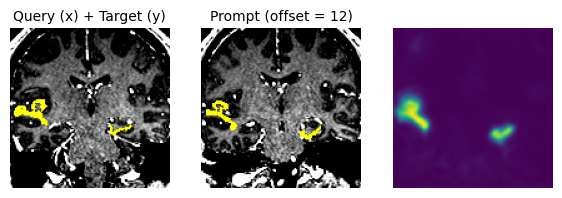

Creating new Data Points ...
Creating new Data Points ...
It took 31 seconds
Epoch   51  loss: 0.111104
Epoch   52  loss: 0.107767
Epoch   53  loss: 0.099804
Epoch   54  loss: 0.098431
Epoch   55  loss: 0.098182
Epoch   56  loss: 0.097362
Epoch   57  loss: 0.096236
Epoch   58  loss: 0.097595
Epoch   59  loss: 0.094284
Epoch   60  loss: 0.092191
Epoch   61  loss: 0.091501
Epoch   62  loss: 0.091081
Epoch   63  loss: 0.089436


2026-04-17 08:54:36.944151: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch   64  loss: 0.089393
Epoch   65  loss: 0.088820
Epoch   66  loss: 0.089101
Epoch   67  loss: 0.088216
Epoch   68  loss: 0.087260
Epoch   69  loss: 0.087085
Epoch   70  loss: 0.083789
Epoch   71  loss: 0.086698
Epoch   72  loss: 0.084833
Epoch   73  loss: 0.083206
Epoch   74  loss: 0.084912
Epoch   75  loss: 0.086052
Epoch   76  loss: 0.085969
Epoch   77  loss: 0.084400
Epoch   78  loss: 0.080898
Epoch   79  loss: 0.079903
Epoch   80  loss: 0.079933
Epoch   81  loss: 0.082156
Epoch   82  loss: 0.083396
Epoch   83  loss: 0.080934
Epoch   84  loss: 0.081121
Epoch   85  loss: 0.079204
Epoch   86  loss: 0.080453
Epoch   87  loss: 0.078320
Epoch   88  loss: 0.079461
Epoch   89  loss: 0.079038
Epoch   90  loss: 0.078543
Epoch   91  loss: 0.077352
Epoch   92  loss: 0.076529
Epoch   93  loss: 0.078512
Epoch   94  loss: 0.076670
Epoch   95  loss: 0.074733
Epoch   96  loss: 0.076940
Epoch   97  loss: 0.077117
Epoch   98  loss: 0.075054
Epoch   99  loss: 0.074476
Epoch  100  loss: 0.074025


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4756271..3.570509].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..3.570509].


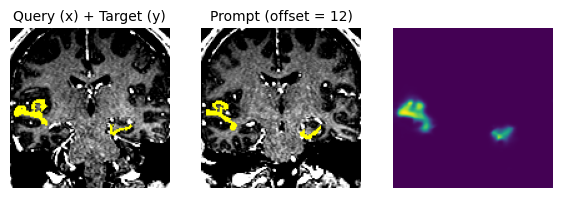

Creating new Data Points ...
Creating new Data Points ...
It took 46 seconds
Epoch  101  loss: 0.119019
Epoch  102  loss: 0.116919
Epoch  103  loss: 0.111428
Epoch  104  loss: 0.106371
Epoch  105  loss: 0.099853
Epoch  106  loss: 0.096807
Epoch  107  loss: 0.095477
Epoch  108  loss: 0.093949
Epoch  109  loss: 0.093223
Epoch  110  loss: 0.091880
Epoch  111  loss: 0.093073
Epoch  112  loss: 0.089057
Epoch  113  loss: 0.086631
Epoch  114  loss: 0.089090
Epoch  115  loss: 0.089804
Epoch  116  loss: 0.090058
Epoch  117  loss: 0.086815
Epoch  118  loss: 0.086498
Epoch  119  loss: 0.088615
Epoch  120  loss: 0.084473
Epoch  121  loss: 0.084333
Epoch  122  loss: 0.084583
Epoch  123  loss: 0.084312
Epoch  124  loss: 0.083179
Epoch  125  loss: 0.085066
Epoch  126  loss: 0.080675
Epoch  127  loss: 0.083899


2026-04-17 09:14:22.133996: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch  128  loss: 0.081551
Epoch  129  loss: 0.082537
Epoch  130  loss: 0.081364
Epoch  131  loss: 0.080398
Epoch  132  loss: 0.079361
Epoch  133  loss: 0.081173
Epoch  134  loss: 0.081439
Epoch  135  loss: 0.081192
Epoch  136  loss: 0.079684
Epoch  137  loss: 0.078504
Epoch  138  loss: 0.079098
Epoch  139  loss: 0.077487
Epoch  140  loss: 0.079233
Epoch  141  loss: 0.075986
Epoch  142  loss: 0.077255
Epoch  143  loss: 0.081594
Epoch  144  loss: 0.075418
Epoch  145  loss: 0.076588
Epoch  146  loss: 0.075600
Epoch  147  loss: 0.077357
Epoch  148  loss: 0.076376
Epoch  149  loss: 0.073161
Epoch  150  loss: 0.074164


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4756271..3.570509].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..3.570509].


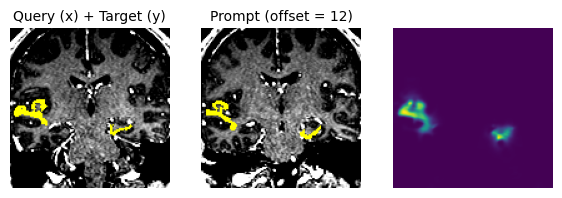

Creating new Data Points ...
Creating new Data Points ...
It took 59 seconds
Epoch  151  loss: 0.092713
Epoch  152  loss: 0.088373
Epoch  153  loss: 0.085958
Epoch  154  loss: 0.085733
Epoch  155  loss: 0.084252
Epoch  156  loss: 0.082323
Epoch  157  loss: 0.080827
Epoch  158  loss: 0.080123
Epoch  159  loss: 0.080137
Epoch  160  loss: 0.078905
Epoch  161  loss: 0.078408
Epoch  162  loss: 0.077008
Epoch  163  loss: 0.080037
Epoch  164  loss: 0.079577
Epoch  165  loss: 0.077381
Epoch  166  loss: 0.076363
Epoch  167  loss: 0.075459
Epoch  168  loss: 0.073549
Epoch  169  loss: 0.074598
Epoch  170  loss: 0.077069
Epoch  171  loss: 0.074853
Epoch  172  loss: 0.073786
Epoch  173  loss: 0.072752
Epoch  174  loss: 0.073329
Epoch  175  loss: 0.072150
Epoch  176  loss: 0.070787
Epoch  177  loss: 0.072548
Epoch  178  loss: 0.072805
Epoch  179  loss: 0.070041
Epoch  180  loss: 0.070499
Epoch  181  loss: 0.071035
Epoch  182  loss: 0.069302
Epoch  183  loss: 0.068971
Epoch  184  loss: 0.069157
Epoch

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4756271..3.570509].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..3.570509].


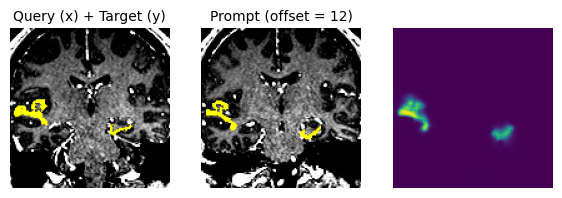

Creating new Data Points ...
Creating new Data Points ...
It took 42 seconds
Epoch  201  loss: 0.086918
Epoch  202  loss: 0.082311
Epoch  203  loss: 0.079496
Epoch  204  loss: 0.078133
Epoch  205  loss: 0.077428
Epoch  206  loss: 0.076384
Epoch  207  loss: 0.075404
Epoch  208  loss: 0.074692
Epoch  209  loss: 0.075889
Epoch  210  loss: 0.073885
Epoch  211  loss: 0.074083
Epoch  212  loss: 0.071221
Epoch  213  loss: 0.070619
Epoch  214  loss: 0.070268
Epoch  215  loss: 0.070133
Epoch  216  loss: 0.069249
Epoch  217  loss: 0.069792
Epoch  218  loss: 0.069018
Epoch  219  loss: 0.068414
Epoch  220  loss: 0.068175
Epoch  221  loss: 0.068801
Epoch  222  loss: 0.069193
Epoch  223  loss: 0.068380
Epoch  224  loss: 0.066208
Epoch  225  loss: 0.066270
Epoch  226  loss: 0.065401
Epoch  227  loss: 0.066157
Epoch  228  loss: 0.064666
Epoch  229  loss: 0.064895
Epoch  230  loss: 0.065779
Epoch  231  loss: 0.063583
Epoch  232  loss: 0.065085
Epoch  233  loss: 0.064377
Epoch  234  loss: 0.063825
Epoch

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4756271..3.570509].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..3.570509].


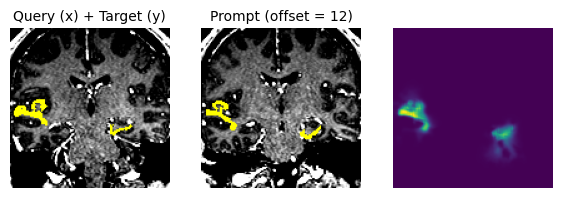

Creating new Data Points ...
Creating new Data Points ...
It took 80 seconds
Epoch  251  loss: 0.106768
Epoch  252  loss: 0.098818
Epoch  253  loss: 0.097744
Epoch  254  loss: 0.092292
Epoch  255  loss: 0.089306


2026-04-17 09:52:58.012903: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch  256  loss: 0.089229
Epoch  257  loss: 0.086980
Epoch  258  loss: 0.084528
Epoch  259  loss: 0.082747
Epoch  260  loss: 0.084490
Epoch  261  loss: 0.083873
Epoch  262  loss: 0.081081
Epoch  263  loss: 0.083022
Epoch  264  loss: 0.081553
Epoch  265  loss: 0.079834
Epoch  266  loss: 0.076669
Epoch  267  loss: 0.077215
Epoch  268  loss: 0.077283
Epoch  269  loss: 0.078066
Epoch  270  loss: 0.078247
Epoch  271  loss: 0.077349
Epoch  272  loss: 0.075887
Epoch  273  loss: 0.076487
Epoch  274  loss: 0.074864
Epoch  275  loss: 0.073446
Epoch  276  loss: 0.073256
Epoch  277  loss: 0.071181
Epoch  278  loss: 0.071555
Epoch  279  loss: 0.072235
Epoch  280  loss: 0.072046
Epoch  281  loss: 0.071061
Epoch  282  loss: 0.069579
Epoch  283  loss: 0.070824
Epoch  284  loss: 0.068444
Epoch  285  loss: 0.071415
Epoch  286  loss: 0.072534
Epoch  287  loss: 0.071498
Epoch  288  loss: 0.068734
Epoch  289  loss: 0.070258
Epoch  290  loss: 0.069766
Epoch  291  loss: 0.070076
Epoch  292  loss: 0.068684
E

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4756271..3.570509].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..3.570509].


  Validation loss: 0.4131


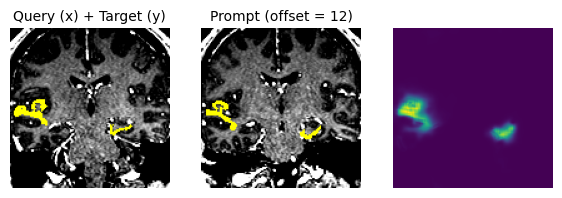

Creating new Data Points ...
Creating new Data Points ...
It took 107 seconds
Epoch  301  loss: 0.103005
Epoch  302  loss: 0.095545
Epoch  303  loss: 0.091463
Epoch  304  loss: 0.088476
Epoch  305  loss: 0.086904
Epoch  306  loss: 0.086272
Epoch  307  loss: 0.084818
Epoch  308  loss: 0.086110
Epoch  309  loss: 0.081642
Epoch  310  loss: 0.081362
Epoch  311  loss: 0.080570
Epoch  312  loss: 0.080816
Epoch  313  loss: 0.081160
Epoch  314  loss: 0.078192
Epoch  315  loss: 0.077929
Epoch  316  loss: 0.078665
Epoch  317  loss: 0.077620
Epoch  318  loss: 0.077651
Epoch  319  loss: 0.078754
Epoch  320  loss: 0.077188
Epoch  321  loss: 0.076765
Epoch  322  loss: 0.076604
Epoch  323  loss: 0.075038
Epoch  324  loss: 0.075355
Epoch  325  loss: 0.074712
Epoch  326  loss: 0.073322
Epoch  327  loss: 0.074134
Epoch  328  loss: 0.073444
Epoch  329  loss: 0.072826
Epoch  330  loss: 0.072399
Epoch  331  loss: 0.073158
Epoch  332  loss: 0.072424
Epoch  333  loss: 0.071047
Epoch  334  loss: 0.070964
Epoc

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4756271..3.570509].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..3.570509].


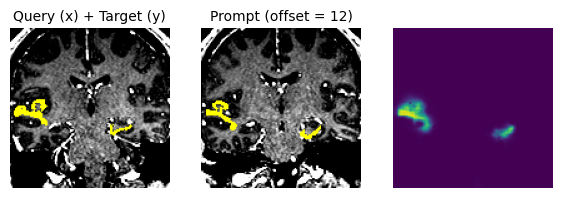

Creating new Data Points ...
Creating new Data Points ...
It took 42 seconds
Epoch  351  loss: 0.085232
Epoch  352  loss: 0.078346
Epoch  353  loss: 0.075226
Epoch  354  loss: 0.072507
Epoch  355  loss: 0.070193
Epoch  356  loss: 0.067472
Epoch  357  loss: 0.067050
Epoch  358  loss: 0.065354
Epoch  359  loss: 0.066022
Epoch  360  loss: 0.066662
Epoch  361  loss: 0.067291
Epoch  362  loss: 0.064836
Epoch  363  loss: 0.063834
Epoch  364  loss: 0.062369
Epoch  365  loss: 0.062492
Epoch  366  loss: 0.063988
Epoch  367  loss: 0.061102
Epoch  368  loss: 0.062592
Epoch  369  loss: 0.061501
Epoch  370  loss: 0.062377
Epoch  371  loss: 0.060674
Epoch  372  loss: 0.059648
Epoch  373  loss: 0.058313
Epoch  374  loss: 0.059367
Epoch  375  loss: 0.060913
Epoch  376  loss: 0.060337
Epoch  377  loss: 0.058726
Epoch  378  loss: 0.059281
Epoch  379  loss: 0.060678
Epoch  380  loss: 0.058512
Epoch  381  loss: 0.057866
Epoch  382  loss: 0.056677
Epoch  383  loss: 0.057810
Epoch  384  loss: 0.057533
Epoch

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4756271..3.570509].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..3.570509].


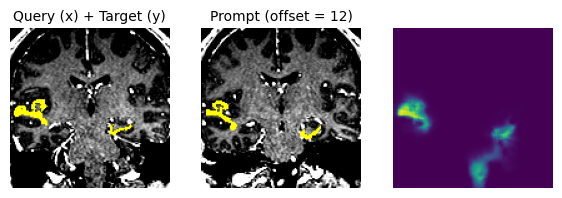

Creating new Data Points ...
Creating new Data Points ...
It took 43 seconds
Epoch  401  loss: 0.089621
Epoch  402  loss: 0.078225
Epoch  403  loss: 0.072874
Epoch  404  loss: 0.072639
Epoch  405  loss: 0.067694
Epoch  406  loss: 0.067252
Epoch  407  loss: 0.066866
Epoch  408  loss: 0.070892
Epoch  409  loss: 0.067061
Epoch  410  loss: 0.066047
Epoch  411  loss: 0.063204
Epoch  412  loss: 0.063104
Epoch  413  loss: 0.060791
Epoch  414  loss: 0.060275
Epoch  415  loss: 0.061481
Epoch  416  loss: 0.061235
Epoch  417  loss: 0.060782
Epoch  418  loss: 0.060174
Epoch  419  loss: 0.062344
Epoch  420  loss: 0.058696
Epoch  421  loss: 0.059077
Epoch  422  loss: 0.061039
Epoch  423  loss: 0.059144
Epoch  424  loss: 0.056974
Epoch  425  loss: 0.056927
Epoch  426  loss: 0.057008
Epoch  427  loss: 0.054751
Epoch  428  loss: 0.057317
Epoch  429  loss: 0.057639
Epoch  430  loss: 0.056401
Epoch  431  loss: 0.055161
Epoch  432  loss: 0.054490
Epoch  433  loss: 0.056071
Epoch  434  loss: 0.056637
Epoch

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4756271..3.570509].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..3.570509].


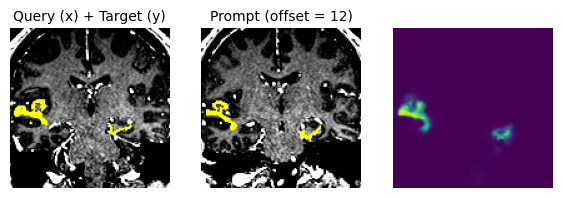

Creating new Data Points ...
Creating new Data Points ...
It took 75 seconds
Epoch  451  loss: 0.090034
Epoch  452  loss: 0.078613
Epoch  453  loss: 0.075480
Epoch  454  loss: 0.074289
Epoch  455  loss: 0.071911
Epoch  456  loss: 0.068832
Epoch  457  loss: 0.069324
Epoch  458  loss: 0.067050
Epoch  459  loss: 0.065907
Epoch  460  loss: 0.063096
Epoch  461  loss: 0.065710
Epoch  462  loss: 0.064471
Epoch  463  loss: 0.064533
Epoch  464  loss: 0.063071
Epoch  465  loss: 0.064156
Epoch  466  loss: 0.061413
Epoch  467  loss: 0.060599
Epoch  468  loss: 0.058609
Epoch  469  loss: 0.060863
Epoch  470  loss: 0.060183
Epoch  471  loss: 0.059958
Epoch  472  loss: 0.060623
Epoch  473  loss: 0.059035
Epoch  474  loss: 0.056883
Epoch  475  loss: 0.057316
Epoch  476  loss: 0.056265
Epoch  477  loss: 0.059051
Epoch  478  loss: 0.060275
Epoch  479  loss: 0.057501
Epoch  480  loss: 0.058872
Epoch  481  loss: 0.056326
Epoch  482  loss: 0.055480
Epoch  483  loss: 0.055831
Epoch  484  loss: 0.057798
Epoch

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4756271..3.570509].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..3.570509].


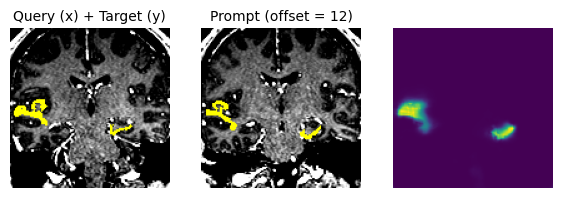

Creating new Data Points ...
Creating new Data Points ...
It took 23 seconds
Epoch  501  loss: 0.071291
Epoch  502  loss: 0.058240
Epoch  503  loss: 0.055166
Epoch  504  loss: 0.053275
Epoch  505  loss: 0.052486
Epoch  506  loss: 0.050725
Epoch  507  loss: 0.050807
Epoch  508  loss: 0.049586
Epoch  509  loss: 0.048094
Epoch  510  loss: 0.048432


2026-04-17 11:13:54.462732: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch  511  loss: 0.047299
Epoch  512  loss: 0.048271
Epoch  513  loss: 0.046967
Epoch  514  loss: 0.046883
Epoch  515  loss: 0.046695
Epoch  516  loss: 0.045608
Epoch  517  loss: 0.044652
Epoch  518  loss: 0.044968
Epoch  519  loss: 0.044814
Epoch  520  loss: 0.044348
Epoch  521  loss: 0.043806
Epoch  522  loss: 0.043662
Epoch  523  loss: 0.043279
Epoch  524  loss: 0.043002
Epoch  525  loss: 0.043194
Epoch  526  loss: 0.042454
Epoch  527  loss: 0.042553
Epoch  528  loss: 0.042351
Epoch  529  loss: 0.042045
Epoch  530  loss: 0.041016
Epoch  531  loss: 0.041636
Epoch  532  loss: 0.040957
Epoch  533  loss: 0.041342
Epoch  534  loss: 0.040977
Epoch  535  loss: 0.041883
Epoch  536  loss: 0.041084
Epoch  537  loss: 0.040653
Epoch  538  loss: 0.041077
Epoch  539  loss: 0.040871
Epoch  540  loss: 0.040052
Epoch  541  loss: 0.041272
Epoch  542  loss: 0.040391
Epoch  543  loss: 0.039766
Epoch  544  loss: 0.039597
Epoch  545  loss: 0.039580
Epoch  546  loss: 0.039522
Epoch  547  loss: 0.038286
E

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4756271..3.570509].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..3.570509].


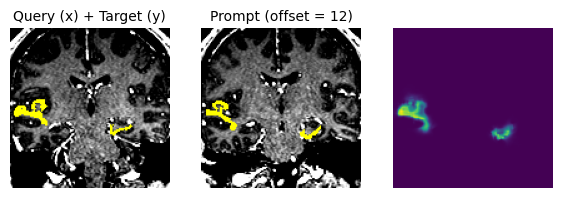

Creating new Data Points ...
Creating new Data Points ...
It took 116 seconds
Epoch  551  loss: 0.077928
Epoch  552  loss: 0.065440
Epoch  553  loss: 0.062708
Epoch  554  loss: 0.058402
Epoch  555  loss: 0.056777
Epoch  556  loss: 0.057436
Epoch  557  loss: 0.052921
Epoch  558  loss: 0.053934
Epoch  559  loss: 0.054260
Epoch  560  loss: 0.052000
Epoch  561  loss: 0.052220
Epoch  562  loss: 0.049558
Epoch  563  loss: 0.047771
Epoch  564  loss: 0.046398
Epoch  565  loss: 0.050123
Epoch  566  loss: 0.047132
Epoch  567  loss: 0.047147
Epoch  568  loss: 0.048579
Epoch  569  loss: 0.046226
Epoch  570  loss: 0.045267
Epoch  571  loss: 0.045757
Epoch  572  loss: 0.045259
Epoch  573  loss: 0.045133
Epoch  574  loss: 0.042671
Epoch  575  loss: 0.045169
Epoch  576  loss: 0.044382
Epoch  577  loss: 0.041987
Epoch  578  loss: 0.042999
Epoch  579  loss: 0.044087
Epoch  580  loss: 0.042410
Epoch  581  loss: 0.043124
Epoch  582  loss: 0.042199
Epoch  583  loss: 0.041357
Epoch  584  loss: 0.041148
Epoc

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4756271..3.570509].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..3.570509].


  Validation loss: 0.3708


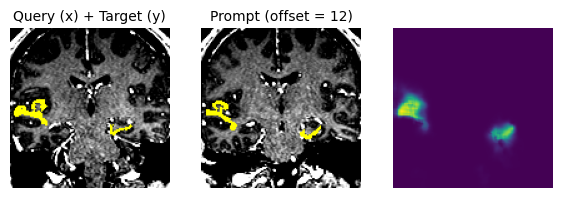

Creating new Data Points ...
Creating new Data Points ...
It took 86 seconds
Epoch  601  loss: 0.072481
Epoch  602  loss: 0.061094
Epoch  603  loss: 0.058732
Epoch  604  loss: 0.056780
Epoch  605  loss: 0.056152
Epoch  606  loss: 0.055460
Epoch  607  loss: 0.052587
Epoch  608  loss: 0.052644
Epoch  609  loss: 0.053573
Epoch  610  loss: 0.050833
Epoch  611  loss: 0.051530
Epoch  612  loss: 0.051106
Epoch  613  loss: 0.049895
Epoch  614  loss: 0.049162
Epoch  615  loss: 0.050534
Epoch  616  loss: 0.049999
Epoch  617  loss: 0.048471
Epoch  618  loss: 0.047365
Epoch  619  loss: 0.048050
Epoch  620  loss: 0.048348
Epoch  621  loss: 0.046030
Epoch  622  loss: 0.045530
Epoch  623  loss: 0.046189
Epoch  624  loss: 0.045709
Epoch  625  loss: 0.045807
Epoch  626  loss: 0.045770
Epoch  627  loss: 0.047937
Epoch  628  loss: 0.044210
Epoch  629  loss: 0.046494
Epoch  630  loss: 0.045694
Epoch  631  loss: 0.043462
Epoch  632  loss: 0.044891
Epoch  633  loss: 0.044714
Epoch  634  loss: 0.043337
Epoch

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4756271..3.570509].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..3.570509].


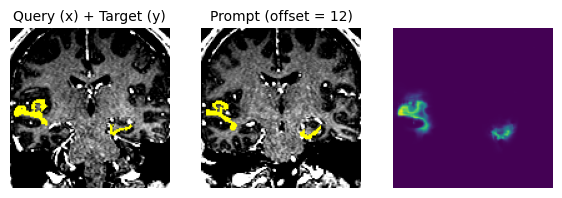

Creating new Data Points ...
Creating new Data Points ...
It took 57 seconds
Epoch  651  loss: 0.070411
Epoch  652  loss: 0.063684
Epoch  653  loss: 0.059015
Epoch  654  loss: 0.057495
Epoch  655  loss: 0.056986
Epoch  656  loss: 0.053305
Epoch  657  loss: 0.054664
Epoch  658  loss: 0.052912
Epoch  659  loss: 0.051018
Epoch  660  loss: 0.051858
Epoch  661  loss: 0.051670
Epoch  662  loss: 0.049607
Epoch  663  loss: 0.050920
Epoch  664  loss: 0.049494
Epoch  665  loss: 0.049197
Epoch  666  loss: 0.049584
Epoch  667  loss: 0.049054
Epoch  668  loss: 0.047495
Epoch  669  loss: 0.047978
Epoch  670  loss: 0.048182
Epoch  671  loss: 0.047133
Epoch  672  loss: 0.045868
Epoch  673  loss: 0.046819
Epoch  674  loss: 0.046777
Epoch  675  loss: 0.045761
Epoch  676  loss: 0.045563
Epoch  677  loss: 0.047051
Epoch  678  loss: 0.047049
Epoch  679  loss: 0.045760
Epoch  680  loss: 0.044882
Epoch  681  loss: 0.043682
Epoch  682  loss: 0.043713
Epoch  683  loss: 0.042709
Epoch  684  loss: 0.042475
Epoch

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4756271..3.570509].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..3.570509].


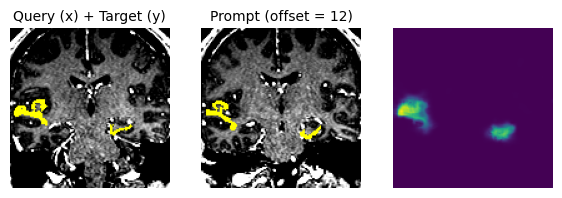

Creating new Data Points ...
Creating new Data Points ...
It took 90 seconds
Epoch  701  loss: 0.078819
Epoch  702  loss: 0.066149
Epoch  703  loss: 0.064614
Epoch  704  loss: 0.063509
Epoch  705  loss: 0.059536
Epoch  706  loss: 0.059691
Epoch  707  loss: 0.057785
Epoch  708  loss: 0.056854
Epoch  709  loss: 0.056239
Epoch  710  loss: 0.055892
Epoch  711  loss: 0.056257
Epoch  712  loss: 0.055238
Epoch  713  loss: 0.053581
Epoch  714  loss: 0.052299
Epoch  715  loss: 0.052417
Epoch  716  loss: 0.051597
Epoch  717  loss: 0.051608
Epoch  718  loss: 0.050553
Epoch  719  loss: 0.049733
Epoch  720  loss: 0.052254
Epoch  721  loss: 0.050484
Epoch  722  loss: 0.050220
Epoch  723  loss: 0.048722
Epoch  724  loss: 0.049706
Epoch  725  loss: 0.048800
Epoch  726  loss: 0.048300
Epoch  727  loss: 0.048950
Epoch  728  loss: 0.047899
Epoch  729  loss: 0.048103
Epoch  730  loss: 0.047133
Epoch  731  loss: 0.048230
Epoch  732  loss: 0.047692
Epoch  733  loss: 0.046964
Epoch  734  loss: 0.047543
Epoch

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4756271..3.570509].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..3.570509].


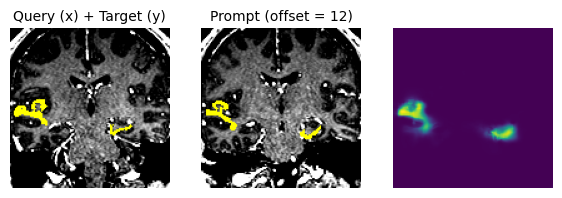

Creating new Data Points ...
Creating new Data Points ...
It took 50 seconds
Epoch  751  loss: 0.076216
Epoch  752  loss: 0.067320
Epoch  753  loss: 0.064412
Epoch  754  loss: 0.063777
Epoch  755  loss: 0.062666
Epoch  756  loss: 0.060194
Epoch  757  loss: 0.058862
Epoch  758  loss: 0.058744
Epoch  759  loss: 0.058303
Epoch  760  loss: 0.057802
Epoch  761  loss: 0.056146
Epoch  762  loss: 0.057086
Epoch  763  loss: 0.055559


In [ ]:
def fit(epochs):
    mlflow.set_experiment(version)

    with mlflow.start_run():

        mlflow.log_params({
            "batch_size"        : batch_size,
            "max_number_labels" : max_number_labels,
            "num_epochs"        : epochs,
            "dp_training"       : dp_training,
            "offset"            : offset,
            "loss_function"     : "binary_crossentropy",
            "warmup_epochs"     : warmup_epochs,
            "flat_epochs"       : flat_epochs,
            "prob_geometric"    : augmenter.prob_geometric,
            "prob_morph"        : augmenter.prob_morph,
            "gamma_range"       : str(augmenter.gamma_range),
            "trainable_params"  : model.this.count_params(),
        })

        # ── Validation dataset (built once, no augmentation) ───────────────────
        val_x, val_y, val_p, val_m, _ = datagenerator.get_val_data_points_numpy(
            max_data_points   = dp_testing,
            offset            = offset,
            max_number_labels = max_number_labels,
        )
        test_ds = (
            tf.data.Dataset.from_tensor_slices((val_x, val_y, val_p, val_m))
            .batch(1)
        )

        # ── Prime the training buffer before the loop ──────────────────────────
        refresh_train_data()

        for epoch in range(epochs):

            model.train_loss.reset_state()

            # Log learning rate
            lr = model.optimizer.learning_rate
            if isinstance(lr, tf.keras.optimizers.schedules.LearningRateSchedule):
                lr = float(lr(epoch * steps_per_epoch))  # evaluate at actual step
            else:
                lr = float(lr.numpy())
            mlflow.log_metric("learning_rate", lr, step=epoch)

            # Checkpoint every 8 epochs
            if epoch % 8 == 0 and epoch != 0:
                model.this.save(f"{version}.keras")

            # Validation every new_val_loop epochs
            if epoch % new_val_loop == 0 and epoch != 0:
                total_dice = 0.0
                for z in test_ds:
                    pred = model.this([z[0], z[2]], training=False)
                    total_dice += float(dice_score_tf(z[1][..., 0:1], pred))
                val_loss = 1.0 - total_dice / dp_testing
                mlflow.log_metric("validation_loss", val_loss, step=epoch)
                print(f"  Validation loss: {val_loss:.4f}")

            # Refresh training data every new_ds epochs
            if epoch % new_ds == 0 and epoch != 0:
                # Visualise one validation prediction
                z_test = next(iter(test_ds))
                pred   = model.this([z_test[0], z_test[2]], training=False)
                plot_result(z_test[0][0], z_test[1][0], z_test[2][0], pred[0], offset, "")

                # Swap numpy buffer — pipeline graph stays intact
                refresh_train_data()

            # Train one epoch (dataset is already mapped/batched/prefetched)
            model.train_epoch(train_dataset=train_ds)

            epoch_loss = float(model.train_loss.result())
            print(f"Epoch {epoch + 1:>4d}  loss: {epoch_loss:.6f}")
            mlflow.log_metric("train_loss", epoch_loss, step=epoch)


fit(epochs)